# Data Cleaning & Preparation — PySpark Edition

The same thirteen-stage pipeline as `cleaning_and_prep_pipeline.ipynb`, rewritten in the Spark
DataFrame API: profile → clean → engineer → select → scale.

**Dataset:** UCI Bank Marketing (`bank-additional-full.csv`) — 41,188 rows × 21 columns.

**The N/A convention:** every section always runs its detection code. When a check finds nothing
to fix, it prints an explicit `N/A` verdict and the handling step is skipped rather than deleted.

**What changes when you move to Spark.** Every pandas operation here has a Spark equivalent, but
three habits have to go:

1. **Nothing runs until you ask for a result.** `withColumn`, `filter`, and `join` only build a
   plan. `.show()`, `.count()`, `.collect()`, and `.write` are the actions that execute it.
2. **There is no row index and no guaranteed order.** `.head()`, `.iloc`, and `df.duplicated()`
   have no direct translation. Order must be stated explicitly with `orderBy` or a `Window`.
3. **Never `.toPandas()` a large frame.** Aggregate in Spark first, collect the small result.
   Every plot below follows that rule.

## 0. Setup

In [1]:
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as func
from pyspark.sql.types import (StructType, StructField, IntegerType, DoubleType, StringType)
from pyspark.ml.feature import (Bucketizer, MinMaxScaler, OneHotEncoder, QuantileDiscretizer,
                                StandardScaler, StringIndexer, VectorAssembler)
# A Spark ML vector is a VectorUDT struct, NOT an array -- element_at/[i] do not work on it.
from pyspark.ml.functions import vector_to_array

# local[*] uses every core on this machine. On a cluster this is the only line that changes.
spark = (SparkSession.builder
         .appName("BankMarketingCleaningPipeline")
         .master("local[*]")
         .config("spark.sql.shuffle.partitions", "8")   # default 200 is far too many locally
         .getOrCreate())

# Spark logs INFO by default and drowns the notebook output
spark.sparkContext.setLogLevel("ERROR")

def verdict(applies, message):
    """Uniform section verdict. Returns the flag so callers can gate the handling step."""
    print(("APPLIES  — " if applies else "N/A      — ") + message)
    return applies

# localCheckpoint() below needs somewhere to spill to
spark.sparkContext.setCheckpointDir("Data/_checkpoints")

print("Spark", spark.version, "| partitions:", spark.sparkContext.defaultParallelism)

Spark 3.5.5 | partitions: 24


In [2]:
# An explicit schema beats inferSchema: it skips the extra read pass Spark uses to guess
# types, and it fails loudly if the file shape changes instead of silently typing a column
# as string.
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("job", StringType(), True),
    StructField("marital", StringType(), True),
    StructField("education", StringType(), True),
    StructField("default", StringType(), True),
    StructField("housing", StringType(), True),
    StructField("loan", StringType(), True),
    StructField("contact", StringType(), True),
    StructField("month", StringType(), True),
    StructField("day_of_week", StringType(), True),
    StructField("duration", IntegerType(), True),
    StructField("campaign", IntegerType(), True),
    StructField("pdays", IntegerType(), True),
    StructField("previous", IntegerType(), True),
    StructField("poutcome", StringType(), True),
    StructField("emp_var_rate", DoubleType(), True),
    StructField("cons_price_idx", DoubleType(), True),
    StructField("cons_conf_idx", DoubleType(), True),
    StructField("euribor3m", DoubleType(), True),
    StructField("nr_employed", DoubleType(), True),
    StructField("y", StringType(), True),
])

# Renaming the dotted columns in the schema (emp.var.rate -> emp_var_rate) avoids having to
# backtick-quote them in every later expression.
raw = (spark.read
       .option("header", "true")
       .option("sep", ";")
       .schema(schema)
       .csv("Data/bank-additional-full.csv"))

DATA_COLS = raw.columns   # the 21 real columns, before we add anything of our own

# A Spark DataFrame has NO row order. The file is chronological and section 9d needs that
# fact, so capture it HERE -- immediately after the read, before any filter, join, or
# dropDuplicates can shuffle the rows and destroy it. After a shuffle it is unrecoverable.
raw = raw.withColumn("row_id", func.monotonically_increasing_id())

# cache(): this frame is read many times below. Without it Spark re-reads the CSV every action.
raw.cache()
print("rows:", raw.count(), "| columns:", len(DATA_COLS), "(+ row_id)")

rows: 41188 | columns: 21 (+ row_id)


## 1. First Look

`.show()` replaces `.head()`, `.printSchema()` replaces `.info()`, and `.describe()` /
`.summary()` replace `pandas.describe()`.

In [3]:
raw.show(5, truncate=False)

+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+---------+-----------+---+------+
|age|job      |marital|education  |default|housing|loan|contact  |month|day_of_week|duration|campaign|pdays|previous|poutcome   |emp_var_rate|cons_price_idx|cons_conf_idx|euribor3m|nr_employed|y  |row_id|
+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+---------+-----------+---+------+
|56 |housemaid|married|basic.4y   |no     |no     |no  |telephone|may  |mon        |261     |1       |999  |0       |nonexistent|1.1         |93.994        |-36.4        |4.857    |5191.0     |no |0     |
|57 |services |married|high.school|unknown|no     |no  |telephone|may  |mon        |149     |1       |999  |0       |nonexistent|1.1         |93.994        |-36.4        |4.857    

In [4]:
raw.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- month: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- emp_var_rate: double (nullable = true)
 |-- cons_price_idx: double (nullable = true)
 |-- cons_conf_idx: double (nullable = true)
 |-- euribor3m: double (nullable = true)
 |-- nr_employed: double (nullable = true)
 |-- y: string (nullable = true)
 |-- row_id: long (nullable = false)



In [5]:
# .summary() gives the percentiles .describe() leaves out
raw.select("age", "duration", "campaign", "pdays", "previous").summary().show()

+-------+------------------+------------------+-----------------+-----------------+-------------------+
|summary|               age|          duration|         campaign|            pdays|           previous|
+-------+------------------+------------------+-----------------+-----------------+-------------------+
|  count|             41188|             41188|            41188|            41188|              41188|
|   mean| 40.02406040594348| 258.2850101971448|2.567592502670681|962.4754540157328|0.17296299893172767|
| stddev|10.421249980934057|259.27924883646455|2.770013542902331|186.9109073447414|0.49490107983928927|
|    min|                17|                 0|                1|                0|                  0|
|    25%|                32|               102|                1|              999|                  0|
|    50%|                38|               180|                2|              999|                  0|
|    75%|                47|               319|                3

In [6]:
# The categorical equivalent of describe(include="object"): distinct counts per column.
# One pass, one row out -- countDistinct over every string column at once.
str_cols = [f.name for f in raw.schema.fields if f.dataType == StringType()]
raw.select([func.countDistinct(func.col(c)).alias(c) for c in str_cols]).show(truncate=False)

+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+---+
|job|marital|education|default|housing|loan|contact|month|day_of_week|poutcome|y  |
+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+---+
|12 |4      |8        |3      |3      |3   |2      |10   |5          |3       |2  |
+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+---+



## 2. Data Types

The schema above already fixed what `inferSchema` would have guessed. What remains is
turning the target into a number.

In [7]:
# when/otherwise is Spark's np.where. Chain .when() calls for the np.select equivalent.
df = raw.withColumn("y", func.when(func.col("y") == "yes", 1).otherwise(0))

df.groupBy("y").count().orderBy("y").show()
rate = df.select(func.avg("y")).first()[0]
print(f"positive rate: {rate:.1%}")

+---+-----+
|  y|count|
+---+-----+
|  0|36548|
|  1| 4640|
+---+-----+



positive rate: 11.3%


### Converting to Numeric

In [8]:
# In pandas this is pd.to_numeric on a "$45,000" string. In Spark it is .cast(), and the
# tell-tale of a bad cast is nulls appearing where there were none: cast() returns null
# rather than raising, exactly like errors="coerce".
numeric_names = ["age", "duration", "campaign", "pdays", "previous",
                 "emp_var_rate", "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed"]

before = df.select([func.count(func.when(func.col(c).isNull(), c)).alias(c)
                    for c in numeric_names]).first().asDict()
casted = df.select([func.col(c).cast("double").alias(c) for c in numeric_names])
after = casted.select([func.count(func.when(func.col(c).isNull(), c)).alias(c)
                       for c in numeric_names]).first().asDict()

new_nulls = {c: after[c] - before[c] for c in numeric_names if after[c] > before[c]}
verdict(bool(new_nulls), f"columns that lost values to a cast: {new_nulls or 'none — every numeric column is genuinely numeric'}")

N/A      — columns that lost values to a cast: none — every numeric column is genuinely numeric


False

## 3. Missing Data

### a. Find missing data

In [9]:
# There is no .isna().sum() -- build it as one aggregate over every column.
null_row = df.select([func.count(func.when(func.col(c).isNull(), c)).alias(c)
                      for c in df.columns]).first().asDict()
total_nulls = sum(null_row.values())

verdict(total_nulls > 0, f"Spark-visible nulls: {total_nulls} across {sum(1 for v in null_row.values() if v)} columns")

N/A      — Spark-visible nulls: 0 across 0 columns


False

In [10]:
# The real lesson, unchanged from pandas: missing data is disguised as a legal value.
unknown_counts = df.select([func.count(func.when(func.col(c) == "unknown", c)).alias(c)
                            for c in str_cols if c != "y"]).first().asDict()

print("Disguised as the string 'unknown':")
for c, n in sorted(unknown_counts.items(), key=lambda kv: -kv[1]):
    if n:
        print(f"   {c:<12} {n:>6,}  ({n/41188:>5.1%})")

sentinel = df.filter(func.col("pdays") == 999).count()
print("Disguised as the sentinel 999:")
print(f"   {'pdays':<12} {sentinel:>6,}  = 'never previously contacted'")

Disguised as the string 'unknown':
   default       8,597  (20.9%)
   education     1,731  ( 4.2%)
   housing         990  ( 2.4%)
   loan            990  ( 2.4%)
   job             330  ( 0.8%)
   marital          80  ( 0.2%)


Disguised as the sentinel 999:
   pdays        39,673  = 'never previously contacted'


### b. Handle missing data — i. Dropping missing values

In [11]:
# Price the drop before taking it. na.drop() is Spark's dropna(); "any" is the default.
as_missing = df
for c in str_cols:
    if c != "y":
        as_missing = as_missing.withColumn(c, func.when(func.col(c) == "unknown", None).otherwise(func.col(c)))

kept = as_missing.na.drop(how="any").count()
print(f"na.drop(how='any'): 41,188 -> {kept:,} rows kept ({1 - kept/41188:.0%} destroyed)")

# The column-wise equivalent: Spark has no dropna(axis=1), so compute it explicitly.
dirty_cols = [c for c, n in unknown_counts.items() if n]
print(f"dropping affected columns instead: {len(df.columns)} -> {len(df.columns) - len(dirty_cols)} columns")

verdict(False, "dropping is too expensive here — impute and flag instead (below)")

na.drop(how='any'): 41,188 -> 30,488 rows kept (26% destroyed)
dropping affected columns instead: 22 -> 16 columns
N/A      — dropping is too expensive here — impute and flag instead (below)


False

### b. Handle missing data — ii. Imputing missing values

In [12]:
# Spark has no .mode(). Compute it as a groupBy/count/orderBy and take the first row.
def mode_of(frame, column):
    return (frame.filter(func.col(column) != "unknown")
                 .groupBy(column).count()
                 .orderBy(func.desc("count"))
                 .first()[0])

impute_cols = ["job", "marital", "education", "housing", "loan"]
modes = {c: mode_of(df, c) for c in impute_cols}

for c, m in modes.items():
    df = df.withColumn(c, func.when(func.col(c) == "unknown", func.lit(m)).otherwise(func.col(c)))
    print(f"   {c:<12} 'unknown' -> '{m}'")

# 'default' keeps its unknowns on purpose: 21% is too many to impute, and the refusal
# to answer is itself signal.

# pdays: the 999 sentinel becomes a real null plus an explicit flag.
df = (df.withColumn("was_contacted_before", func.when(func.col("pdays") != 999, 1).otherwise(0))
        .withColumn("pdays", func.when(func.col("pdays") == 999, None).otherwise(func.col("pdays"))))

print(f"   pdays        999 -> null, flag set on {df.agg(func.sum('was_contacted_before')).first()[0]:,} rows")
df.cache().count()

   job          'unknown' -> 'admin.'
   marital      'unknown' -> 'married'
   education    'unknown' -> 'university.degree'
   housing      'unknown' -> 'yes'
   loan         'unknown' -> 'no'
   pdays        999 -> null, flag set on 1,515 rows


41188

## 4. Inconsistent Text and Typos

### a. Find inconsistent text and typos

In [13]:
# One aggregate answers both questions for every string column: how many values change
# under trim(), and how many under lower().
checks = []
for c in str_cols:
    if c == "y":
        continue
    checks += [
        func.count(func.when(func.col(c) != func.trim(func.col(c)), c)).alias(f"{c}__ws"),
        (func.countDistinct(func.col(c)) - func.countDistinct(func.lower(func.col(c)))).alias(f"{c}__case"),
    ]

row = df.select(checks).first().asDict()
issues = sorted({k.split("__")[0] for k, v in row.items() if v}, key=str)

for c in issues:
    print(f"   {c:<12} whitespace: {row[c + '__ws']:<6} case-collisions: {row[c + '__case']}")

verdict(bool(issues), f"{len(issues)} column(s) with whitespace or case inconsistencies")

N/A      — 0 column(s) with whitespace or case inconsistencies


False

In [14]:
# Always read the actual category lists. collect() is safe here: these are tiny.
for c in ["job", "marital", "education", "poutcome"]:
    vals = sorted(r[0] for r in df.select(c).distinct().collect())
    print(f"{c} ({len(vals)}):")
    print(f"   {vals}")
    print()

job (11):
   ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed']



marital (3):
   ['divorced', 'married', 'single']

education (7):
   ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree']



poutcome (3):
   ['failure', 'nonexistent', 'success']



### b. Handle inconsistent text and typos

In [15]:
if issues:
    for c in issues:
        df = df.withColumn(c, func.lower(func.trim(func.col(c))))
    print("normalised:", issues)
else:
    verdict(False, "no whitespace/case repairs needed; categories already consistent")

# The reusable recipe, for when it IS needed:
#   df = df.withColumn(c, func.lower(func.trim(func.col(c))))
#   df = df.withColumn(c, func.regexp_replace(c, "highschool", "high.school"))
#   df = df.replace({"n/a": None}, subset=[c])

N/A      — no whitespace/case repairs needed; categories already consistent


## 5. Duplicate Rows

### a. Find duplicate rows

In [16]:
# There is no .duplicated() -- group by every column and keep the groups bigger than one.
# GOTCHA: group by DATA_COLS, not df.columns. row_id is unique by construction, so
# including it would make every row its own group and report zero duplicates.
groups = df.groupBy(DATA_COLS).count().filter(func.col("count") > 1).cache()

n_groups = groups.count()
extra_rows = groups.select(func.sum(func.col("count") - 1)).first()[0] or 0

verdict(n_groups > 0, f"{extra_rows} duplicate row(s) to drop across {n_groups} group(s)")
groups.select("age", "job", "marital", "education", "month", "count").show(5, truncate=False)

APPLIES  — 12 duplicate row(s) to drop across 12 group(s)
+---+----------+--------+-------------------+-----+-----+
|age|job       |marital |education          |month|count|
+---+----------+--------+-------------------+-----+-----+
|27 |technician|single  |professional.course|jul  |2    |
|45 |admin.    |married |university.degree  |jul  |2    |
|47 |technician|divorced|high.school        |jul  |2    |
|39 |admin.    |married |university.degree  |nov  |2    |
|41 |technician|married |professional.course|aug  |2    |
+---+----------+--------+-------------------+-----+-----+
only showing top 5 rows



### b. Handle duplicate rows

In [17]:
rows_before = df.count()

# Same trap as above: a bare dropDuplicates() would compare row_id too and remove nothing.
df = df.dropDuplicates(subset=DATA_COLS).cache()
print(f"{rows_before:,} -> {df.count():,} rows  ({rows_before - df.count()} removed)")

# Proof of the trap, rather than an assertion to take on trust:
print(f"dropDuplicates() including row_id would have removed "
      f"{rows_before - df.dropDuplicates().count()} rows")

# The other half of the trap: dropDuplicates(subset) keeps an ARBITRARY row from each
# group, not the first, because there is no row order to define "first". Use a Window
# with row_number() when which row survives actually matters.

41,188 -> 41,176 rows  (12 removed)


dropDuplicates() including row_id would have removed 12 rows


## 6. Outliers

### a. Find outliers — i. Histograms

Never `.toPandas()` the raw column. Bucket it in Spark and collect the ~30 bin counts.

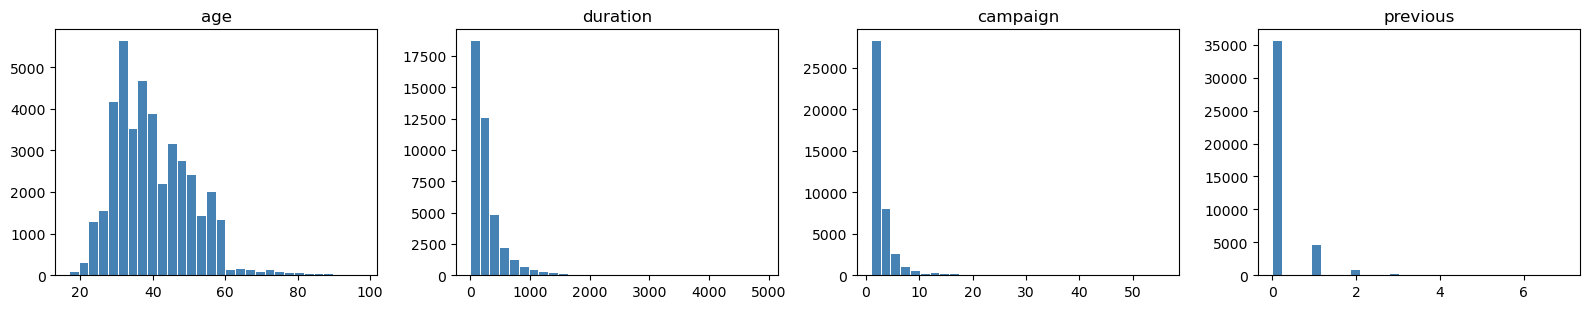

In [18]:
num_cols = ["age", "duration", "campaign", "previous"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, c in zip(axes, num_cols):
    # .histogram() is an RDD action that does the bucketing on the cluster
    edges, counts = df.select(func.col(c).cast("double")).rdd.flatMap(lambda r: r).histogram(30)
    centres = [(edges[i] + edges[i + 1]) / 2 for i in range(len(counts))]
    ax.bar(centres, counts, width=(edges[1] - edges[0]) * 0.9, color="steelblue")
    ax.set_title(c)
plt.tight_layout(); plt.show()

### a. Find outliers — ii. Quantiles (the box-plot numbers)

Spark has no boxplot. `approxQuantile` gives the five numbers a box plot draws, computed
in one pass without sorting the whole column.

In [19]:
box = []
for c in num_cols:
    q = df.approxQuantile(c, [0.0, 0.25, 0.5, 0.75, 1.0], 0.001)   # 0.001 = relative error
    iqr = q[3] - q[1]
    box.append((c, *[round(v, 1) for v in q], round(q[3] + 1.5 * iqr, 1)))

print(f"{'column':<10} {'min':>8} {'q1':>8} {'median':>8} {'q3':>8} {'max':>8} {'iqr_fence':>10}")
for r in box:
    print(f"{r[0]:<10} {r[1]:>8} {r[2]:>8} {r[3]:>8} {r[4]:>8} {r[5]:>8} {r[6]:>10}")

column          min       q1   median       q3      max  iqr_fence
age            17.0     32.0     38.0     47.0     98.0       69.5
duration        0.0    102.0    179.0    319.0   4918.0      644.5
campaign        1.0      1.0      2.0      3.0     56.0        6.0
previous        0.0      0.0      0.0      0.0      7.0        0.0


### a. Find outliers — iii. Standard deviation

In [20]:
# One pass computes mean and stddev for every column at once.
aggs = []
for c in num_cols:
    aggs += [func.mean(c).alias(f"{c}__mean"), func.stddev(c).alias(f"{c}__sd")]
stats = df.select(aggs).first().asDict()

print(f"{'column':<10} {'mean':>9} {'sd':>9} {'3sd_upper':>11} {'n_beyond':>9}")
for c in num_cols:
    hi = stats[f"{c}__mean"] + 3 * stats[f"{c}__sd"]
    n = df.filter(func.col(c) > hi).count()
    print(f"{c:<10} {stats[f'{c}__mean']:>9.1f} {stats[f'{c}__sd']:>9.1f} {hi:>11.1f} {n:>9,}")

column          mean        sd   3sd_upper  n_beyond
age             40.0      10.4        71.3       369


duration       258.3     259.3      1036.2       861
campaign         2.6       2.8        10.9       869


previous         0.2       0.5         1.7     1,064


### b. Handle outliers — i. Remove an entire row or column

In [21]:
# 'duration' is target leakage: the call length is only known once the call has ended, by
# which point the outcome is known too. Dropping the COLUMN is the fix; dropping outlier
# rows would not address leakage at all.
df = df.drop("duration")
print("dropped column 'duration' (target leakage, not an outlier problem)")
print("remaining columns:", len(df.columns))

dropped column 'duration' (target leakage, not an outlier problem)
remaining columns: 22


### b. Handle outliers — ii. Impute the data

In [22]:
# Cap rather than delete: least() is Spark's Series.clip(upper=...).
q1, q3 = df.approxQuantile("campaign", [0.25, 0.75], 0.001)
cap = q3 + 1.5 * (q3 - q1)

n_capped = df.filter(func.col("campaign") > cap).count()
df = df.withColumn("campaign_capped", func.least(func.col("campaign"), func.lit(cap)))

mx = df.select(func.max("campaign"), func.max("campaign_capped")).first()
print(f"campaign: capped {n_capped:,} rows at {cap:.0f} (max was {mx[0]}, now {mx[1]:.0f})")

campaign: capped 2,406 rows at 6 (max was 56, now 6)


### b. Handle outliers — iii. Resolve outliers based on domain expertise

In [23]:
# A statistical rule flags the age tail. Domain knowledge says retirees are a real and
# valuable term-deposit segment, so those rows are true values, not errors.
old = df.filter(func.col("age") > 69)
n_old = old.count()
rate_old = old.select(func.avg("y")).first()[0]
rate_all = df.select(func.avg("y")).first()[0]

print(f"customers over 69: {n_old:,}  ({n_old/df.count():.1%})")
print(f"their subscription rate: {rate_old:.1%}  vs  {rate_all:.1%} overall")
verdict(False, "age tail is genuine signal, not error — keep every row unchanged")

customers over 69: 468  (1.1%)
their subscription rate: 47.2%  vs  11.3% overall
N/A      — age tail is genuine signal, not error — keep every row unchanged


False

### c. Review clean data

In [24]:
n_rows = df.count()
nulls = df.select([func.count(func.when(func.col(c).isNull(), c)).alias(c) for c in df.columns]).first().asDict()
unknowns = df.select([func.count(func.when(func.col(c) == "unknown", c)).alias(c)
                      for c in str_cols if c in df.columns and c != "y"]).first().asDict()
dupes = df.groupBy([c for c in df.columns if c != "row_id"]).count().filter(func.col("count") > 1).count()

print(f"shape:            {n_rows:,} rows x {len(df.columns)} columns")
print(f"nulls:            {sum(nulls.values()):,}  <- all in pdays, created on purpose in 3b")
print(f"'unknown' values: {sum(unknowns.values()):,}  <- all in 'default', kept on purpose")
print(f"duplicate groups: {dupes:,}  <- dropping 'duration' removed the column that told")
print(f"                     otherwise-identical customers apart; these are not repeats")

shape:            41,176 rows x 23 columns
nulls:            39,661  <- all in pdays, created on purpose in 3b
'unknown' values: 8,596  <- all in 'default', kept on purpose
duplicate groups: 1,585  <- dropping 'duration' removed the column that told
                     otherwise-identical customers apart; these are not repeats


## 7. Row Granularity

### a. Group By

In [25]:
# The course idiom: groupBy().agg() with func.round(...).alias(...) for readable output.
by_job = (df.groupBy("job")
            .agg(func.count("*").alias("customers"),
                 func.sum("y").alias("subscribed"),
                 func.round(func.avg("y"), 3).alias("rate"),
                 func.round(func.avg("age"), 1).alias("avg_age"))
            .orderBy(func.desc("rate")))
by_job.show(truncate=False)

+-------------+---------+----------+-----+-------+
|job          |customers|subscribed|rate |avg_age|
+-------------+---------+----------+-----+-------+
|student      |875      |275       |0.314|25.9   |
|retired      |1718     |434       |0.253|62.0   |
|unemployed   |1014     |144       |0.142|39.7   |
|admin.       |10749    |1388      |0.129|38.4   |
|management   |2924     |328       |0.112|42.4   |
|technician   |6739     |730       |0.108|38.5   |
|self-employed|1421     |149       |0.105|39.9   |
|housemaid    |1060     |106       |0.1  |45.5   |
|entrepreneur |1456     |124       |0.085|41.7   |
|services     |3967     |323       |0.081|37.9   |
|blue-collar  |9253     |638       |0.069|39.6   |
+-------------+---------+----------+-----+-------+



### b. Pivot

In [26]:
# Spark's pivot is a groupBy modifier, and it always aggregates -- there is no unaggregated
# .pivot() to trip over the way pandas has. Listing the values explicitly avoids the extra
# job Spark otherwise runs to discover them.
edu_levels = sorted(r[0] for r in df.select("education").distinct().collect())

(df.groupBy("job")
   .pivot("education", edu_levels)
   .agg(func.round(func.avg("y"), 3))
   .orderBy("job")
   .show(truncate=False))

+-------------+--------+--------+--------+-----------+----------+-------------------+-----------------+
|job          |basic.4y|basic.6y|basic.9y|high.school|illiterate|professional.course|university.degree|
+-------------+--------+--------+--------+-----------+----------+-------------------+-----------------+
|admin.       |0.109   |0.052   |0.081   |0.114      |0.0       |0.133              |0.144            |
|blue-collar  |0.053   |0.075   |0.066   |0.107      |0.0       |0.091              |0.06             |
|entrepreneur |0.051   |0.127   |0.057   |0.068      |0.5       |0.067              |0.105            |
|housemaid    |0.108   |0.065   |0.032   |0.08       |0.0       |0.186              |0.122            |
|management   |0.05    |0.118   |0.066   |0.057      |NULL      |0.09               |0.127            |
|retired      |0.31    |0.133   |0.131   |0.225      |0.667     |0.237              |0.26             |
|self-employed|0.032   |0.04    |0.082   |0.068      |0.333     

## 8. Conditional Logic and Categorical Encoding

### a. Conditional Logic

In [27]:
# Chained .when() is np.select; a single .when().otherwise() is np.where.
df = (df
      .withColumn("age_group", func.when(func.col("age") < 30, "young")
                                   .when(func.col("age") < 60, "middle")
                                   .otherwise("senior"))
      .withColumn("contacted_by_cell", func.when(func.col("contact") == "cellular", 1).otherwise(0)))

df.select("age", "age_group", "contact", "contacted_by_cell").show(5)

+---+---------+---------+-----------------+
|age|age_group|  contact|contacted_by_cell|
+---+---------+---------+-----------------+
| 52|   middle| cellular|                1|
| 41|   middle|telephone|                0|
| 24|    young|telephone|                0|
| 57|   middle|telephone|                0|
| 54|   middle|telephone|                0|
+---+---------+---------+-----------------+
only showing top 5 rows



### b. Categorical Encoding

`pd.get_dummies` has no direct equivalent, and that is deliberate. Spark encodes in two
stages so the mapping is a fitted object you can reuse on new data instead of a column
layout that silently changes when a category is missing from the next batch.

In [28]:
encode_cols = ["job", "marital", "education", "contact", "poutcome", "age_group"]

# 1. StringIndexer: text -> ordinal index, ordered by frequency
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            for c in encode_cols]
# 2. OneHotEncoder: index -> sparse vector. dropLast=True is drop_first=True.
encoder = OneHotEncoder(inputCols=[f"{c}_idx" for c in encode_cols],
                        outputCols=[f"{c}_vec" for c in encode_cols],
                        dropLast=True)

encoded = df
for ix in indexers:
    encoded = ix.fit(encoded).transform(encoded)
encoded = encoder.fit(encoded).transform(encoded)

# Six fitted models now sit in this plan. Materialise once so Catalyst stops
# re-analysing the whole tree on every later action.
encoded = encoded.localCheckpoint(eager=True)

total_levels = sum(len(sorted(r[0] for r in df.select(c).distinct().collect())) for c in encode_cols)
print(f"{len(encode_cols)} categorical columns, {total_levels} levels -> {len(encode_cols)} sparse vector columns")
encoded.select("job", "job_idx", "job_vec").show(3, truncate=False)

6 categorical columns, 29 levels -> 6 sparse vector columns
+-----------+-------+--------------+
|job        |job_idx|job_vec       |
+-----------+-------+--------------+
|admin.     |0.0    |(11,[0],[1.0])|
|blue-collar|1.0    |(11,[1],[1.0])|
|technician |2.0    |(11,[2],[1.0])|
+-----------+-------+--------------+
only showing top 3 rows



## 9. Feature Engineering

### a. Applying Calculations

In [29]:
encoded = (encoded
           .withColumn("contacts_total", func.col("campaign") + func.col("previous"))
           .withColumn("prev_success_rate",
                       func.when(func.col("previous") > 0,
                                 func.when(func.col("poutcome") == "success", 1).otherwise(0))
                           .otherwise(0)))

encoded.select("campaign", "previous", "contacts_total", "poutcome", "prev_success_rate").show(5)

+--------+--------+--------------+-----------+-----------------+
|campaign|previous|contacts_total|   poutcome|prev_success_rate|
+--------+--------+--------------+-----------+-----------------+
|       1|       1|             2|    success|                1|
|       1|       0|             1|nonexistent|                0|
|       1|       0|             1|nonexistent|                0|
|       1|       0|             1|nonexistent|                0|
|       1|       0|             1|nonexistent|                0|
+--------+--------+--------------+-----------+-----------------+
only showing top 5 rows



### b. Binning Values

In [30]:
# Bucketizer is pd.cut: fixed edges you choose. -inf/inf guard against unseen values.
age_bucketizer = Bucketizer(splits=[-float("inf"), 30, 45, 60, float("inf")],
                            inputCol="age", outputCol="age_band")

# QuantileDiscretizer is pd.qcut: equal-frequency bins. Like pandas it silently returns
# FEWER buckets when one value dominates -- 43% of rows have campaign == 1.
campaign_binner = QuantileDiscretizer(numBuckets=4, inputCol="campaign",
                                      outputCol="campaign_quartile", relativeError=0.001)

encoded = age_bucketizer.transform(encoded)
encoded = campaign_binner.fit(encoded).transform(encoded)

encoded.groupBy("age_band").count().orderBy("age_band").show()
encoded.groupBy("campaign_quartile").count().orderBy("campaign_quartile").show()

asked, got = 4, encoded.select("campaign_quartile").distinct().count()
print(f"asked for {asked} equal-frequency bins, got {got}")

+--------+-----+
|age_band|count|
+--------+-----+
|     0.0| 5667|
|     1.0|22579|
|     2.0|11738|
|     3.0| 1192|
+--------+-----+

+-----------------+-----+
|campaign_quartile|count|
+-----------------+-----+
|              1.0|17634|
|              2.0|10568|
|              3.0|12974|
+-----------------+-----+



asked for 4 equal-frequency bins, got 3


### c. Proxy Variables

In [31]:
# A proxy stands in for something the data does not measure directly.
euribor_splits = df.approxQuantile("euribor3m", [0.33, 0.66], 0.001)
climate = Bucketizer(splits=[-float("inf")] + euribor_splits + [float("inf")],
                     inputCol="euribor3m", outputCol="econ_climate")

encoded = climate.transform(encoded)
encoded = encoded.withColumn("known_customer", func.when(func.col("previous") > 0, 1).otherwise(0))

encoded.groupBy("econ_climate").agg(func.count("*").alias("n"),
                                    func.round(func.avg("y"), 3).alias("rate")).orderBy("econ_climate").show()
encoded.groupBy("known_customer").agg(func.count("*").alias("n"),
                                      func.round(func.avg("y"), 3).alias("rate")).orderBy("known_customer").show()

+------------+-----+-----+
|econ_climate|    n| rate|
+------------+-----+-----+
|         0.0|13508|0.244|
|         1.0|13492|0.043|
|         2.0|14176|0.053|
+------------+-----+-----+

+--------------+-----+-----+
|known_customer|    n| rate|
+--------------+-----+-----+
|             0|35551|0.088|
|             1| 5625|0.266|
+--------------+-----+-----+



### d. Creating Columns From DateTime Columns

The file has `month` and `day_of_week` as text but no year. In pandas the year came from a
cumulative count of month rollovers over row order. **That technique does not port directly**,
and the reason is the single most important difference between the two APIs.

`df.month.shift()` in pandas relies on the index. Spark has no index, and by this point the
frame has been through `dropDuplicates`, a shuffle that reorders rows arbitrarily. Calling
`monotonically_increasing_id()` *here* numbers the rows in their post-shuffle order, so the
month sequence jumps around and every jump reads as a year rollover — the run below produced
years from 2013 to 2027 before this was fixed.

The fix is the `row_id` captured in section 0, immediately after the read and before any
shuffle. Order must be **materialised as data** while it still exists.

In [32]:
MONTHS = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
          "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}

month_expr = func.create_map([func.lit(x) for kv in MONTHS.items() for x in kv])
encoded = encoded.withColumn("month_num", month_expr[func.col("month")])

# Order by the row_id captured at read time -- NOT by monotonically_increasing_id() called
# here, which would describe the current post-shuffle order.
# A Window with no partitionBy also forces every row onto ONE executor. Spark warns about
# it, and on a genuinely large dataset this line is where the job would fall over. It is
# acceptable here only because the recovery is inherently sequential and the data is 41k rows.
order = Window.orderBy("row_id")
running = Window.orderBy("row_id").rowsBetween(Window.unboundedPreceding, 0)

encoded = (encoded
           .withColumn("prev_month", func.lag("month_num").over(order))
           .withColumn("rollover", func.when(func.col("month_num") < func.col("prev_month"), 1).otherwise(0))
           .withColumn("year", 2008 + func.sum("rollover").over(running))
           .withColumn("contact_date", func.make_date(func.col("year"), func.col("month_num"), func.lit(1))))

# Break the lineage here. By this point the plan carries ~50 chained transformations plus
# six fitted ML models; leaving it lazy makes Catalyst re-analyse the whole tree on every
# subsequent action and it eventually fails outright.
encoded = encoded.localCheckpoint(eager=True)

encoded.groupBy("year").agg(func.count("*").alias("rows"),
                            func.countDistinct("month").alias("months")).orderBy("year").show()
span = encoded.select(func.min("contact_date"), func.max("contact_date")).first()
print(f"span: {span[0]:%b %Y} -> {span[1]:%b %Y}")

+----+-----+------+
|year| rows|months|
+----+-----+------+
|2008|27682|     7|
|2009|11436|    10|
|2010| 2058|     9|
+----+-----+------+

span: May 2008 -> Nov 2010


### e. Durations

In [33]:
# Spark has no timedelta dtype. Seconds stay an integer, and you either format them or
# build a real INTERVAL with make_interval.
call = raw.select(func.col("duration").alias("secs"))

stats = call.select(func.avg("secs").alias("mean"), func.max("secs").alias("max"),
                    func.sum("secs").alias("total")).first()

fmt = lambda s: f"{int(s)//3600}h {int(s)%3600//60}m {int(s)%60}s"
print(f"mean call: {fmt(stats['mean'])}")
print(f"longest:   {fmt(stats['max'])}")
print(f"total time on the phone: {stats['total']/86400:.1f} days")

# As a true interval type, which can be added to a timestamp
call.select(func.make_interval(secs=func.col("secs").cast("decimal(10,6)")).alias("as_interval")).show(3, truncate=False)

mean call: 0h 4m 18s
longest:   1h 21m 58s
total time on the phone: 123.1 days


+--------------------+
|as_interval         |
+--------------------+
|4 minutes 21 seconds|
|2 minutes 29 seconds|
|3 minutes 46 seconds|
+--------------------+
only showing top 3 rows



### f. Extracting DateTime Components

In [34]:
encoded = (encoded
           .withColumn("quarter", func.quarter("contact_date"))
           .withColumn("month_name", func.date_format("contact_date", "MMMM"))
           .withColumn("is_q4", func.when(func.quarter("contact_date") == 4, 1).otherwise(0))
           .withColumn("months_elapsed",
                       func.months_between(func.col("contact_date"),
                                           func.lit("2008-05-01").cast("date")).cast("int")))

encoded.select("contact_date", "year", "quarter", "month_name", "is_q4", "months_elapsed").show(5)

+------------+----+-------+----------+-----+--------------+
|contact_date|year|quarter|month_name|is_q4|months_elapsed|
+------------+----+-------+----------+-----+--------------+
|  2008-05-01|2008|      2|       May|    0|             0|
|  2008-05-01|2008|      2|       May|    0|             0|
|  2008-05-01|2008|      2|       May|    0|             0|
|  2008-05-01|2008|      2|       May|    0|             0|
|  2008-05-01|2008|      2|       May|    0|             0|
+------------+----+-------+----------+-----+--------------+
only showing top 5 rows



### g. Creating Columns From Text Columns

In [35]:
# split() returns an array column -- index it with [0], [1] rather than expand=True.
parts = func.split(func.col("education"), "\\.")

encoded = (encoded
           .withColumn("edu_level", parts.getItem(0))
           .withColumn("edu_detail", parts.getItem(1))
           # regexp_extract is .str.extract; group 1 is the captured digits
           .withColumn("edu_digits", func.regexp_extract(func.col("education"), r"(\d+)", 1))
           .withColumn("is_university", func.when(func.col("education").contains("university"), 1).otherwise(0)))

# regexp_extract returns "" (not null) when nothing matches -- 70% of rows here. Fill it
# from domain knowledge, exactly as the pandas version does.
YEARS = {"illiterate": 0, "basic.4y": 4, "basic.6y": 6, "basic.9y": 9,
         "high.school": 12, "professional.course": 13, "university.degree": 16}
years_map = func.create_map([func.lit(x) for kv in YEARS.items() for x in kv])

blank = encoded.filter(func.col("edu_digits") == "").count()
print(f"regexp_extract left {blank:,} rows blank ({blank/encoded.count():.0%}) — filling from the schooling map")

encoded = encoded.withColumn("edu_years", years_map[func.col("education")].cast("double"))
encoded.select("education", "edu_level", "edu_detail", "edu_digits", "edu_years", "is_university").distinct().orderBy("education").show(truncate=False)

regexp_extract left 28,664 rows blank (70%) — filling from the schooling map


+-------------------+------------+----------+----------+---------+-------------+
|education          |edu_level   |edu_detail|edu_digits|edu_years|is_university|
+-------------------+------------+----------+----------+---------+-------------+
|basic.4y           |basic       |4y        |4         |4.0      |0            |
|basic.6y           |basic       |6y        |6         |6.0      |0            |
|basic.9y           |basic       |9y        |9         |9.0      |0            |
|high.school        |high        |school    |          |12.0     |0            |
|illiterate         |illiterate  |NULL      |          |0.0      |0            |
|professional.course|professional|course    |          |13.0     |0            |
|university.degree  |university  |degree    |          |16.0     |1            |
+-------------------+------------+----------+----------+---------+-------------+



## 10. Joining External Data

`pd.merge` becomes `.join`. The one addition is `broadcast()`: when one side is small,
shipping a copy to every executor avoids shuffling the large side across the network.

In [36]:
sector_rows = [("admin.", "White collar"), ("blue-collar", "Manual"),
               ("entrepreneur", "Business owner"), ("housemaid", "Service"),
               ("management", "White collar"), ("retired", "Not working"),
               ("self-employed", "Business owner"), ("services", "Service"),
               ("student", "Not working"), ("technician", "Technical"),
               ("unemployed", "Not working")]
sectors = spark.createDataFrame(sector_rows, ["job", "sector"])

before = encoded.count()
encoded = encoded.join(func.broadcast(sectors), on="job", how="left")

# Always check the row count and the unmatched count after a join. A left join that
# multiplies rows means the key is not unique on the right.
unmatched = encoded.filter(func.col("sector").isNull()).count()
print(f"rows: {before:,} -> {encoded.count():,}   unmatched jobs: {unmatched}")

encoded.groupBy("sector").agg(func.count("*").alias("n"),
                              func.round(func.avg("y"), 3).alias("rate")).orderBy(func.desc("rate")).show()

rows: 41,176 -> 41,176   unmatched jobs: 0


+--------------+-----+-----+
|        sector|    n| rate|
+--------------+-----+-----+
|   Not working| 3607|0.236|
|  White collar|13673|0.126|
|     Technical| 6739|0.108|
|Business owner| 2877|0.095|
|       Service| 5027|0.085|
|        Manual| 9253|0.069|
+--------------+-----+-----+



## 11. Feature Selection

### a. Exclude ID and leaky columns

In [37]:
# isin() is the same name in both APIs.
keep_sectors = ["White collar", "Technical", "Business owner"]
print(f"rows in {keep_sectors}: {encoded.filter(func.col('sector').isin(keep_sectors)).count():,}")

id_cols = [c for c in encoded.columns if c.lower() in {"id", "customer_id", "index"}]
verdict(bool(id_cols), f"ID columns found: {id_cols or 'none — this dataset has no identifier column'}")

# 'duration' was already dropped in section 6 for leakage.
print("'duration' still present:", "duration" in encoded.columns)

rows in ['White collar', 'Technical', 'Business owner']: 23,289
N/A      — ID columns found: none — this dataset has no identifier column
'duration' still present: False


### b. Select a subset of features

In [38]:
numeric_features = ["age", "campaign_capped", "previous", "contacts_total",
                    "emp_var_rate", "cons_price_idx", "cons_conf_idx",
                    "euribor3m", "nr_employed", "edu_years", "months_elapsed"]
flag_features = ["was_contacted_before", "contacted_by_cell", "known_customer",
                 "is_university", "is_q4", "prev_success_rate"]
vector_features = [f"{c}_vec" for c in encode_cols]

model_df = encoded.select(numeric_features + flag_features + vector_features + ["y"]).cache()

nulls = model_df.select([func.count(func.when(func.col(c).isNull(), c)).alias(c)
                         for c in numeric_features + flag_features + ["y"]]).first().asDict()
print(f"model frame: {model_df.count():,} rows x {len(model_df.columns)} columns")
print(f"remaining nulls: {sum(nulls.values())}")

model frame: 41,176 rows x 24 columns
remaining nulls: 0


## 12. Feature Scaling

Spark scalers do not take a list of columns. Everything is assembled into a single vector
column first with `VectorAssembler`, and the scaler transforms that one column — the same
shape the course's `real-estate.py` uses before fitting a model.

### a. Normalization (MinMaxScaler)

In [39]:
assembler = VectorAssembler(inputCols=numeric_features, outputCol="features",
                            handleInvalid="skip")
assembled = assembler.transform(model_df)

mm_model = MinMaxScaler(inputCol="features", outputCol="features_norm").fit(assembled)
normalized = mm_model.transform(assembled)

print("original mins:", [round(v, 1) for v in mm_model.originalMin])
print("original maxs:", [round(v, 1) for v in mm_model.originalMax])
normalized.select("features_norm").show(3, truncate=False)

original mins: [17.0, 1.0, 0.0, 1.0, -3.4, 92.2, -50.8, 0.6, 4963.6, 0.0, 0.0]
original maxs: [98.0, 6.0, 7.0, 56.0, 1.4, 94.8, -26.9, 5.0, 5228.1, 16.0, 30.0]
+----------------------------------------------------------------------------------------------------------------------------+
|features_norm                                                                                                               |
+----------------------------------------------------------------------------------------------------------------------------+
|[0.48148148148148145,0.0,0.0,0.0,0.9375,0.6987529228371023,0.602510460251046,0.9573792790750397,0.8597353497164447,0.25,0.0]|
|[0.49382716049382713,0.0,0.0,0.0,0.9375,0.6987529228371023,0.602510460251046,0.9573792790750397,0.8597353497164447,0.75,0.0]|
|[0.24691358024691357,0.0,0.0,0.0,0.9375,0.6987529228371023,0.602510460251046,0.9573792790750397,0.8597353497164447,0.75,0.0]|
+-----------------------------------------------------------------------------

### b. Standardization (StandardScaler)

In [40]:
std_model = StandardScaler(inputCol="features", outputCol="features_std",
                           withMean=True, withStd=True).fit(assembled)
standardized = std_model.transform(assembled)

print("column means:", [round(v, 2) for v in std_model.mean])
print("column sds:  ", [round(v, 2) for v in std_model.std])
standardized.select("features_std").show(3, truncate=False)

# withMean=True is NOT the default. Leaving it off scales to unit variance but does not
# centre, which quietly breaks any method that assumes zero-mean input.

column means: [40.02, 2.28, 0.17, 2.74, 0.08, 93.58, -40.5, 3.62, 5167.03, 11.89, 6.14]
column sds:   [10.42, 1.55, 0.49, 2.78, 1.57, 0.58, 4.63, 1.73, 72.25, 3.92, 6.81]
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_std                                                                                                                                                                                                              |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[1.5331245109651364,-0.8225662662074232,-0.349547184353933,-0.6272722325889882,0.6480932966550038,0.7226191135462652,0.8865573611916351,0.7124539834843824,0.33169104

### c. `fit` on train, `transform` on test

`randomSplit` replaces the index slice. Fitting the scaler on the full frame would leak
the test set's statistics into training.

In [41]:
train, test = assembled.randomSplit([0.8, 0.2], seed=42)

leak_free = StandardScaler(inputCol="features", outputCol="scaled",
                           withMean=True, withStd=True).fit(train)   # train only

train_scaled = leak_free.transform(train)
test_scaled = leak_free.transform(test)

mean_of = lambda d: d.select(func.avg(vector_to_array("scaled")[0])).first()[0]
print(f"train rows {train.count():,} | test rows {test.count():,}")
print(f"train mean of first feature after scaling: {mean_of(train_scaled):+.6f}   (0 by construction)")
print(f"test  mean of first feature after scaling: {mean_of(test_scaled):+.6f}   (NOT 0 — and that is correct)")

wrong = StandardScaler(inputCol="features", outputCol="scaled2",
                       withMean=True, withStd=True).fit(test).transform(test)
print(f"test  mean if refit (wrong): {wrong.select(func.avg(vector_to_array('scaled2')[0])).first()[0]:+.6f}")

train rows 32,948 | test rows 8,228


train mean of first feature after scaling: +0.000000   (0 by construction)


test  mean of first feature after scaling: +0.019136   (NOT 0 — and that is correct)


test  mean if refit (wrong): -0.000000


## 13. Final Review

In [42]:
final = standardized.select(*numeric_features, *flag_features, *vector_features,
                            "features", "features_std", "y")

print(f"{'stage':<24} {'rows':>8} {'columns':>8}")
print(f"{'raw file':<24} {raw.count():>8,} {len(raw.columns):>8}")
print(f"{'after cleaning':<24} {df.count():>8,} {len(df.columns):>8}")
print(f"{'model frame':<24} {model_df.count():>8,} {len(model_df.columns):>8}")
print(f"{'with scaled vectors':<24} {final.count():>8,} {len(final.columns):>8}")

n_null = final.select([func.count(func.when(func.col(c).isNull(), c)).alias(c)
                       for c in numeric_features + flag_features + ["y"]]).first().asDict()
print()
print(f"nulls in model frame: {sum(n_null.values())}")
print(f"target balance:       {final.select(func.avg('y')).first()[0]:.1%} positive")

assert sum(n_null.values()) == 0, "model frame still has nulls"
print()
print("checks passed: no nulls in the feature columns")

stage                        rows  columns
raw file                   41,188       22
after cleaning             41,176       25


model frame                41,176       24
with scaled vectors        41,176       26



nulls in model frame: 0
target balance:       11.3% positive

checks passed: no nulls in the feature columns


In [43]:
# Parquet, not CSV: it keeps the schema, it keeps the vector columns that CSV cannot
# represent at all, and it is columnar so later reads can skip what they do not need.
OUT = "Data/bank_marketing_spark.parquet"
final.write.mode("overwrite").parquet(OUT)

back = spark.read.parquet(OUT)
print(f"wrote {back.count():,} rows x {len(back.columns)} columns -> {OUT}")

# Compare names and types, which is what actually matters...
same_types = ([(f.name, f.dataType) for f in back.schema.fields]
              == [(f.name, f.dataType) for f in final.schema.fields])
print("names and types survive the round-trip:", same_types)

# ...and note the one thing Parquet does change. Reading it back marks every column
# nullable, so a strict `back.schema == final.schema` is False even though no data moved.
# CSV, by contrast, would have lost the vector columns entirely -- they cannot be
# represented as text at all.
relaxed = [f.name for f in final.schema.fields if not f.nullable]
print(f"columns whose nullable flag Parquet relaxed: {len(relaxed)}")
print("vector columns preserved as VectorUDT:",
      [f.name for f in back.schema.fields if f.dataType.simpleString() == "vector"])

wrote 41,176 rows x 26 columns -> Data/bank_marketing_spark.parquet
names and types survive the round-trip: True
columns whose nullable flag Parquet relaxed: 8
vector columns preserved as VectorUDT: ['job_vec', 'marital_vec', 'education_vec', 'contact_vec', 'poutcome_vec', 'age_group_vec', 'features', 'features_std']


In [44]:
# Always release the cluster. In a notebook this also frees the JVM and the cached frames.
spark.stop()
print("Spark session stopped")

Spark session stopped


### pandas → PySpark translation table

| Step | pandas | PySpark |
| --- | --- | --- |
| Load | `pd.read_csv(sep=";")` | `spark.read.option("sep",";").schema(...).csv(...)` |
| Peek | `.head()` | `.show(5)` |
| Types | `.info()` | `.printSchema()` |
| Stats | `.describe()` | `.summary()` |
| Cast | `pd.to_numeric(errors="coerce")` | `.cast("double")` (nulls on failure) |
| Count nulls | `.isna().sum()` | `select([count(when(col(c).isNull(), c))...])` |
| Drop nulls | `.dropna()` | `.na.drop(how="any")` |
| Fill | `.fillna(v)` | `.na.fill(v)` / `when().otherwise()` |
| Mode | `.mode()[0]` | `groupBy(c).count().orderBy(desc("count")).first()` |
| Conditional | `np.where` / `np.select` | `when().otherwise()` / chained `.when()` |
| Duplicates | `.duplicated()` | `groupBy(df.columns).count().filter(count > 1)` |
| Dedup | `.drop_duplicates()` | `.dropDuplicates()` |
| Percentiles | `np.percentile` | `.approxQuantile(col, probs, err)` |
| Clip | `.clip(upper=x)` | `func.least(col, lit(x))` |
| Group | `.groupby().agg()` | `.groupBy().agg()` |
| Pivot | `.pivot_table()` | `.groupBy().pivot().agg()` |
| Dummies | `pd.get_dummies()` | `StringIndexer` → `OneHotEncoder` |
| Bin (fixed) | `pd.cut` | `Bucketizer` |
| Bin (quantile) | `pd.qcut` | `QuantileDiscretizer` |
| Join | `pd.merge()` | `.join(broadcast(small), on, "left")` |
| Split text | `.str.split(expand=True)` | `func.split(...).getItem(i)` |
| Extract | `.str.extract()` | `func.regexp_extract(col, pattern, group)` |
| Running total | `.cumsum()` | `func.sum().over(Window...rowsBetween(...))` |
| Scale | `MinMaxScaler` on columns | `VectorAssembler` → `MinMaxScaler` on one vector |
| Split | `train_test_split` | `.randomSplit([0.8, 0.2], seed=...)` |
| Save | `.to_csv()` / `.to_pickle()` | `.write.parquet()` |

### Sections that returned N/A on this dataset

| Section | Verdict | Why |
| --- | --- | --- |
| 2. Converting to numeric | N/A | the explicit schema already types every numeric column; no cast loses values |
| 3a. Spark-visible nulls | N/A | zero nulls on read — every missing value is disguised as `"unknown"` or `999` |
| 3b-i. Dropping | N/A | would destroy 26% of rows; imputing and flagging is used instead |
| 4a/4b. Inconsistent text | N/A | categories already lowercase, trimmed, and internally consistent |
| 6b-iii. Outliers by domain | N/A | the age tail is genuine signal, so nothing was changed |
| 11a. ID columns | N/A | the file has no identifier column to exclude |